# 2. Napelemes ML Pipeline – Day-Ahead Termelés-Előrejelzés (TFT)

**Cél:** A DuckDB-ben tárolt pvlib szimulációs adatokra (2023–2024) **Temporal Fusion Transformer (TFT)** modellt tanítunk, amely képes naponta 24 órával előre megjósolni a nettó AC termelést (`p_ac_net`) valószínűségi (P10/P50/P90) bizonytalansági sávokkal.

**Kapcsolat az 1-es notebookban:**
- Az `analysis.ipynb` elvégzi az ETL-t (OpenMeteo letöltés + pvlib szimuláció) és elmenti az adatokat a `solar_data.duckdb` adatbázisba.
- Ez a notebook onnan olvassa be az adatokat – a kettő közötti kapocs kizárólag a DuckDB fájl.

**Pipeline összefoglaló:**
1. DuckDB adatbetöltés (`weather_data` + `pv_results` JOIN)
2. Degradáció + rendszerveszteség alkalmazása → `p_ac_net` célváltozó
3. Időbeli feature-ök (sin/cos kódolás)
4. Darts `TimeSeries` konverzió + skálázás
5. TFT modell tanítása (2023–2024)
6. Gördülő day-ahead backtesting (2025)
7. RMSE / MAPE metrikák
8. Egy véletlen 2025-ös hét vizualizálása (P10/P50/P90)

# 0

In [1]:
import logging
import sys

class ColorFormatter(logging.Formatter):
    """Egyedi formázó, ami log-szint alapján színezi az üzeneteket."""
    GREEN = "\033[32m"
    YELLOW = "\033[33m"
    RED = "\033[31m"
    RESET = "\033[0m"

    # Szabályok: Melyik szint milyen színt kapjon
    FORMATS = {
        logging.DEBUG:    f"%(asctime)s  %(levelname)-8s  %(message)s",
        logging.INFO:     f"{GREEN}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.WARNING:  f"{YELLOW}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.ERROR:    f"{RED}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.CRITICAL: f"{RED}%(asctime)s  %(levelname)-8s{RESET}  %(message)s"
    }

    def format(self, record):
        log_fmt = self.FORMATS.get(record.levelno)
        formatter = logging.Formatter(log_fmt, datefmt="%H:%M:%S")
        return formatter.format(record)

# Logger alaphelyzetbe állítása és az egyedi formázó beállítása
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Töröljük a Jupyter esetleges korábbi (zavaró) logger beállításait
if logger.hasHandlers():
    logger.handlers.clear()

# Új kimeneti csatorna (stdout) felépítése az okos színezővel
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(ColorFormatter())
logger.addHandler(handler)

---
## 1. Importok és konfiguráció

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
import math
import random
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Darts
import os
from darts import TimeSeries, concatenate as darts_concatenate
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import rmse as darts_rmse
from darts.utils.likelihood_models import QuantileRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Projekt konfiguráció
sys.path.insert(0, str(Path.cwd()))
from config import (
    DB_PATH,
    TIMEZONE,
    DETAILED_SYSTEM_LOSSES,
    DEGRADATION_YEAR1,
    DEGRADATION_ANNUAL,
    SIMULATION_BASE_YEAR,
    TRAIN_START, TRAIN_END,
    TEST_START, TEST_END,
    TFT_INPUT_LENGTH, TFT_OUTPUT_LENGTH,
    MPL_DEFAULTS, COLORS,
)

for k, v in MPL_DEFAULTS.items():
    matplotlib.rcParams[k] = v

print("Csomagok sikeresen betöltve.")
print(f"  Darts verzió  : {__import__('darts').__version__}")
print(f"  DuckDB elérési út: {DB_PATH}")

Csomagok sikeresen betöltve.
  Darts verzió  : 0.44.1
  DuckDB elérési út: solar_data.duckdb


---
## 2. Adatok betöltése DuckDB-ből

In [3]:
def load_ml_dataset(db_path: str = DB_PATH) -> pd.DataFrame:
    """Összekapcsolja a weather_data és pv_results táblákat, visszaadja az ML-hez szükséges DataFrame-et."""
    with duckdb.connect(db_path, read_only=True) as con:
        df = con.execute("""
            SELECT
                w.timestamp,
                w.ghi,
                w.temp_air,
                w.wind_speed,
                r.p_ac
            FROM weather_data w
            JOIN pv_results r ON w.timestamp = r.timestamp
            ORDER BY w.timestamp
        """).df()

    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_convert(TIMEZONE)
    df = df.set_index("timestamp").sort_index()
    return df

df_raw = load_ml_dataset()

print(f"Betöltött sorok : {len(df_raw):,}")
print(f"Időszak         : {df_raw.index[0].date()} – {df_raw.index[-1].date()}")
print(f"Oszlopok        : {list(df_raw.columns)}")
df_raw.head(3)

Betöltött sorok : 26,304
Időszak         : 2023-01-01 – 2026-01-01
Oszlopok        : ['ghi', 'temp_air', 'wind_speed', 'p_ac']


,ghi,temp_air,wind_speed,p_ac
timestamp,,,,
2023-01-01 01:00:00+01:00,0.0,7.7,3.51,0.0
2023-01-01 02:00:00+01:00,0.0,7.5,4.02,0.0
2023-01-01 03:00:00+01:00,0.0,7.3,4.14,0.0


---
## 3. Degradáció + rendszerveszteség → `p_ac_net` célváltozó

A Jinko Tiger Neo adatlap szerint:
- **1. év:** −1,0 % (LID + első év degradáció)
- **2+ év:** −0,4 % évente

A rendszerveszteség (soiling, árnyékolás, mismatch stb.) `DETAILED_SYSTEM_LOSSES`-ból számítódik.
A degradáció évente változik, így a modell **látens módon** megtanulja ezt a lassú csökkenést.

In [4]:
# Rendszerveszteség szorzó (időben állandó)
DERATE_FACTOR = math.prod(1.0 - loss for loss in DETAILED_SYSTEM_LOSSES.values())

# Kumulatív degradációs faktorok évenként
def _deg_factor(year: int) -> float:
    years_since_base = year - SIMULATION_BASE_YEAR
    if years_since_base <= 0:
        return 1.0 - DEGRADATION_YEAR1
    return (1.0 - DEGRADATION_YEAR1) * ((1.0 - DEGRADATION_ANNUAL) ** years_since_base)

years_in_data = sorted(df_raw.index.year.unique())
deg_map = {yr: _deg_factor(yr) for yr in years_in_data}

print("Degradációs faktorok:")
for yr, fac in deg_map.items():
    print(f"  {yr}: {fac:.5f}  (veszteség: {(1 - fac)*100:.3f} %)")
print(f"\nRendszerveszteség derate: {DERATE_FACTOR:.4f}  ({(1-DERATE_FACTOR)*100:.2f} %)")

df = df_raw.copy()
df["deg_factor"] = df.index.year.map(deg_map)
df["p_ac_net"] = df["p_ac"] * DERATE_FACTOR * df["deg_factor"]
df = df.drop(columns=["deg_factor", "p_ac"])

print(f"\np_ac_net max   : {df['p_ac_net'].max():.1f} W")
print(f"p_ac_net éves átlag (nappali): {df.loc[df['p_ac_net'] > 1, 'p_ac_net'].mean():.1f} W")

Degradációs faktorok:
  2023: 0.99000  (veszteség: 1.000 %)
  2024: 0.98604  (veszteség: 1.396 %)
  2025: 0.98210  (veszteség: 1.790 %)
  2026: 0.97817  (veszteség: 2.183 %)

Rendszerveszteség derate: 0.8679  (13.21 %)

p_ac_net max   : 2474.6 W
p_ac_net éves átlag (nappali): 1203.8 W


---
## 4. Időbeli feature-ök (ciklikus kódolás)

In [5]:
df["sin_hour"]  = np.sin(2 * np.pi * df.index.hour / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df.index.hour / 24)
df["sin_month"] = np.sin(2 * np.pi * df.index.month / 12)
df["cos_month"] = np.cos(2 * np.pi * df.index.month / 12)

print("Feature-ök hozzáadva:")
print(df[["p_ac_net", "ghi", "temp_air", "wind_speed",
          "sin_hour", "cos_hour", "sin_month", "cos_month"]].describe().round(3))

Feature-ök hozzáadva:
        p_ac_net        ghi   temp_air  wind_speed   sin_hour   cos_hour  \
count  26304.000  26304.000  26304.000   26304.000  26304.000  26304.000   
mean     610.200    157.413     12.647       2.840     -0.000     -0.000   
std      881.881    234.022      9.080       1.508      0.707      0.707   
min        0.000      0.000     -8.300       0.000     -1.000     -1.000   
25%        0.000      0.000      5.200       1.730     -0.707     -0.707   
50%        6.688      6.000     12.400       2.560      0.000     -0.000   
75%     1115.700    263.000     19.700       3.750      0.707      0.707   
max     2474.621    925.000     37.400      10.780      1.000      1.000   

       sin_month  cos_month  
count  26304.000  26304.000  
mean      -0.005     -0.002  
std        0.706      0.708  
min       -1.000     -1.000  
25%       -0.866     -0.866  
50%       -0.000     -0.000  
75%        0.500      0.866  
max        1.000      1.000  


---
## 5. Darts `TimeSeries` konverzió

**Jövőbeli kovariánsok (future covariates):** a day-ahead időjárás-előrejelzésből ismert mennyiségek.
A backtestben a tényleges 2025-ös időjárási adatokat kezeljük úgy, mintha tökéletes másnapi előrejelzések lennének – ez a gördülő előrejelzés standard közelítése.

In [6]:
FUTURE_COV_COLS = [
    "ghi", "temp_air", "wind_speed",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
]

# Darts nem támogatja a timezone-aware DatetimeIndex-et.
# UTC-re konvertálunk, majd levetjük a tz-metaadatot → egyedi, DST-mentes index.
# A sin/cos feature-ök értékei a helyi időből már ki lettek számolva, maradnak helyesek.
df_utc = df.copy()
df_utc.index = df_utc.index.tz_convert("UTC").tz_localize(None)

ts_target = TimeSeries.from_series(
    df_utc["p_ac_net"].rename("p_ac_net"),
    freq="h",
    fill_missing_dates=True,
    fillna_value=0.0,
)

ts_future_cov = TimeSeries.from_dataframe(
    df_utc[FUTURE_COV_COLS],
    freq="h",
    fill_missing_dates=True,
    fillna_value=0.0,
)

print(f"Target TimeSeries  : {len(ts_target):,} időpont (UTC index)")
print(f"  Kezdet           : {ts_target.start_time()}")
print(f"  Vég              : {ts_target.end_time()}")
print(f"Future covariates  : {ts_future_cov.n_components} komponens")

Target TimeSeries  : 26,304 időpont (UTC index)
  Kezdet           : 2023-01-01 00:00:00
  Vég              : 2025-12-31 23:00:00
Future covariates  : 7 komponens


---
## 6. Train/test szétválasztás + skálázás

A scaler-t **csak a tanító adatokon** illesztjük (data leakage elkerülése), majd az összes adaton alkalmazzuk.

In [7]:
def _to_utc(date_str: str) -> pd.Timestamp:
    """Helyi (Budapest) dátumot UTC naív Timestamp-pé alakít – összhangban a TimeSeries UTC indexével."""
    return pd.Timestamp(date_str, tz=TIMEZONE).tz_convert("UTC").tz_localize(None)

TRAIN_START_TS = _to_utc(TRAIN_START)
TRAIN_END_TS   = _to_utc(TRAIN_END) + pd.Timedelta(hours=23)
TEST_START_TS  = _to_utc(TEST_START)
TEST_END_TS    = _to_utc(TEST_END)   + pd.Timedelta(hours=23)

# Tanító részhalmaz a scaler illesztéséhez
ts_train        = ts_target.slice(TRAIN_START_TS, TRAIN_END_TS)
ts_future_train = ts_future_cov.slice(TRAIN_START_TS, TRAIN_END_TS)

# Scaler-ek: célváltozó MinMax [0,1], kovariánsok StandardScaler
scaler_target = Scaler(MinMaxScaler(feature_range=(0.0, 1.0)))
scaler_future = Scaler(StandardScaler())

# Fit a train-en, transform az összes adaton (data leakage elkerülése)
ts_train_scaled        = scaler_target.fit_transform(ts_train)
ts_future_train_scaled = scaler_future.fit_transform(ts_future_train)

ts_target_full_scaled = scaler_target.transform(ts_target)
ts_future_full_scaled = scaler_future.transform(ts_future_cov)

print(f"Train : {ts_train.start_time()} – {ts_train.end_time()}  ({len(ts_train):,} óra)")
print(f"Test  : {TEST_START_TS} – {TEST_END_TS} (UTC)")
print(f"\nTarget skálázva – min: {float(ts_train_scaled.values().min()):.4f}, max: {float(ts_train_scaled.values().max()):.4f}")

Train : 2023-01-01 00:00:00 – 2024-12-31 22:00:00  (17,543 óra)
Test  : 2024-12-31 23:00:00 – 2025-12-31 22:00:00 (UTC)

Target skálázva – min: 0.0000, max: 1.0000


---
## 7. TFT modell felépítése

**Temporal Fusion Transformer** a Darts könyvtárból. `QuantileRegression` likelihood valószínűségi előrejelzéshez.

| Paraméter | Érték | Indoklás |
|---|---|---|
| `input_chunk_length` | 168 óra (7 nap) | Hetente ismétlődő mintázatok tanulása |
| `output_chunk_length` | 24 óra (1 nap) | Day-ahead predikciós horizont |
| `hidden_size` | 64 | Kompromisszum teljesítmény és sebesség között |
| `lstm_layers` | 2 | Kétszintű temporális kódolás |
| `num_attention_heads` | 4 | Multi-head attention |
| `n_epochs` | 20 | Elegendő konvergenciához, CPU-n ~5–15 perc |

In [8]:
FORCE_RETRAIN = False  # True: újratanít és felülírja a checkpointot
MODEL_CHECKPOINT_DIR = "darts_logs/solar_tft_model"

if not FORCE_RETRAIN and os.path.exists(MODEL_CHECKPOINT_DIR):
    # weights_only=False szükséges: PyTorch 2.6 szigorítása miatt a Darts/Lightning
    # saját osztályai (QuantileRegression, LikelihoodType stb.) nem szerepelnek
    # az alapértelmezett biztonságos globálisok között – a checkpoint megbízható forrásból való.
    model = TFTModel.load_from_checkpoint("solar_tft_model", best=False, weights_only=False)
    _needs_training = False
    print("Checkpoint betöltve – tanítás kihagyva.")
    print(f"  Modell: {MODEL_CHECKPOINT_DIR}")
else:
    model = TFTModel(
        input_chunk_length=TFT_INPUT_LENGTH,
        output_chunk_length=TFT_OUTPUT_LENGTH,
        hidden_size=64,
        lstm_layers=2,
        num_attention_heads=4,
        dropout=0.1,
        batch_size=128,
        n_epochs=20,
        likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
        random_state=42,
        add_relative_index=True,
        pl_trainer_kwargs={
            "accelerator": "auto",
            "enable_progress_bar": True,
            "enable_model_summary": False,
        },
        optimizer_kwargs={"lr": 1e-3},
        model_name="solar_tft_model",
        save_checkpoints=True,
        force_reset=True,  # csak új tanításnál jutunk ide
    )
    _needs_training = True
    print("TFT modell létrehozva – tanítás szükséges.")

print(f"  Encoder ablak  : {TFT_INPUT_LENGTH} óra ({TFT_INPUT_LENGTH // 24} nap)")
print(f"  Predikció      : {TFT_OUTPUT_LENGTH} óra (day-ahead)")
print(f"  Kvantilesek    : P10 / P50 / P90")

03:42:17  INFO      loading last-epoch=20.ckpt
Checkpoint betöltve – tanítás kihagyva.
  Modell: darts_logs/solar_tft_model
  Encoder ablak  : 168 óra (7 nap)
  Predikció      : 24 óra (day-ahead)
  Kvantilesek    : P10 / P50 / P90


---
## 8. Betanítás (2023–2024)

> CPU-n várható futásidő: **5–15 perc** (GPU esetén ~1–3 perc). Az `accelerator='auto'` automatikusan GPU-ra vált, ha elérhető.

In [9]:
if _needs_training:
    print("TFT modell betanítása...")
    model.fit(
        series=ts_train_scaled,
        future_covariates=ts_future_train_scaled,
        verbose=True,
    )
    print("\nBetanítás befejezve.")
else:
    print("Checkpoint már betöltve – betanítás kihagyva.")

Checkpoint már betöltve – betanítás kihagyva.


---
## 9. Gördülő day-ahead backtesting (2025)

A `historical_forecasts` minden nap éjfélkor a megelőző 7 nap alapján megjósolja a következő 24 óra termelését. Ez pontosan szimulálja a valós "day-ahead" üzemi forgatókönyvet.

**Adatszivárgás nincs:** a modell minden lépésben csak az adott időpontig ismert adatokat látja.

In [10]:
import pickle

BACKTEST_CACHE = "darts_logs/backtest_scaled.pkl"
FORCE_BACKTEST = False  # True: újra lefuttatja és felülírja a cache-t

if not FORCE_BACKTEST and os.path.exists(BACKTEST_CACHE):
    with open(BACKTEST_CACHE, "rb") as f:
        backtest_scaled = pickle.load(f)
    print(f"Backtest cache betöltve: {BACKTEST_CACHE}")
    print(f"  Előrejelzett ablakok: {len(backtest_scaled):,}")
else:
    print("Gördülő (rolling) day-ahead backtesting 2025-re...")
    print(f"  Időszak   : {TEST_START_TS.date()} – {TEST_END_TS.date()}")
    print(f"  Lépésköz  : {TFT_OUTPUT_LENGTH} óra (naponkénti)", flush=True)

    backtest_scaled = model.historical_forecasts(
        series=ts_target_full_scaled,
        future_covariates=ts_future_full_scaled,
        start=TEST_START_TS,
        forecast_horizon=TFT_OUTPUT_LENGTH,
        stride=TFT_OUTPUT_LENGTH,
        retrain=False,
        verbose=True,
        num_samples=100,
        overlap_end=False,
        last_points_only=False,
        enable_optimization=True,
    )

    with open(BACKTEST_CACHE, "wb") as f:
        pickle.dump(backtest_scaled, f)
    print(f"\nBacktest kész – cache mentve: {BACKTEST_CACHE}")
    print(f"  Előrejelzett ablakok: {len(backtest_scaled):,}")

Backtest cache betöltve: darts_logs/backtest_scaled.pkl
  Előrejelzett ablakok: 365


In [11]:
# backtest_scaled lista (365 × 24h) → egyetlen összefűzött TimeSeries → inverz skálázás
backtest = scaler_target.inverse_transform(darts_concatenate(backtest_scaled))
ts_test_actual = ts_target.slice(TEST_START_TS, TEST_END_TS)

print(f"Előrejelzések inverz transzformálva.")
print(f"  Backtest hossz : {len(backtest):,} óra")
print(f"  Tényleges hossz: {len(ts_test_actual):,} óra")

Előrejelzések inverz transzformálva.
  Backtest hossz : 8,760 óra
  Tényleges hossz: 8,760 óra


---
## 10. Metrikák: RMSE és MAPE

- **RMSE:** az összes 2025-ös órára (éjszakai nulla értékekkel együtt)
- **MAPE:** csak nappali órákra (`p_ac_net > 5 W`), mivel az éjszakai nulla termelés esetén a százalékos hiba értelmetlen

In [12]:
# Kvantilisek egyszeri számítása – egy menetben, ne hívjuk meg 5× külön-külön
_bv = backtest.all_values()   # (T, 1, n_samples) – egyszer allokálva
_t  = backtest.time_index
backtest_p10 = TimeSeries.from_times_and_values(_t, np.quantile(_bv, 0.1, axis=-1))
backtest_p50 = TimeSeries.from_times_and_values(_t, np.quantile(_bv, 0.5, axis=-1))
backtest_p90 = TimeSeries.from_times_and_values(_t, np.quantile(_bv, 0.9, axis=-1))

# Pandas Series-re konvertálás a metrikaszámításhoz
actual_s = ts_test_actual.to_dataframe().squeeze()
p50_s    = backtest_p50.to_dataframe().squeeze()

# Közös időpontok (robusztusság)
common_idx = actual_s.index.intersection(p50_s.index)
actual_s = actual_s.loc[common_idx]
p50_s    = p50_s.loc[common_idx]

# RMSE (minden óra)
rmse_val = np.sqrt(np.mean((actual_s - p50_s) ** 2))

# MAPE (csak nappali órák, ahol tényleges termelés > 5 W)
daytime = actual_s > 5.0
mape_val = np.mean(np.abs((actual_s[daytime] - p50_s[daytime]) / actual_s[daytime])) * 100

print("=" * 55)
print(f"  TFT Day-Ahead Előrejelzés – 2025-ös Teszt Eredmény")
print("=" * 55)
print(f"  RMSE (összes óra)    : {rmse_val:>8.2f} W")
print(f"  MAPE (nappali órák)  : {mape_val:>8.2f} %")
print(f"  Értékelt napok száma : {len(common_idx) // 24}")
print("=" * 55)

  TFT Day-Ahead Előrejelzés – 2025-ös Teszt Eredmény
  RMSE (összes óra)    :    46.88 W
  MAPE (nappali órák)  :     9.38 %
  Értékelt napok száma : 365


---
## 11. Vizualizáció – Véletlen hét 2025-ből (P10 / P50 / P90)

Vizualizált hét: 2024-12-31 – 2025-01-07  (offset: 0/51)


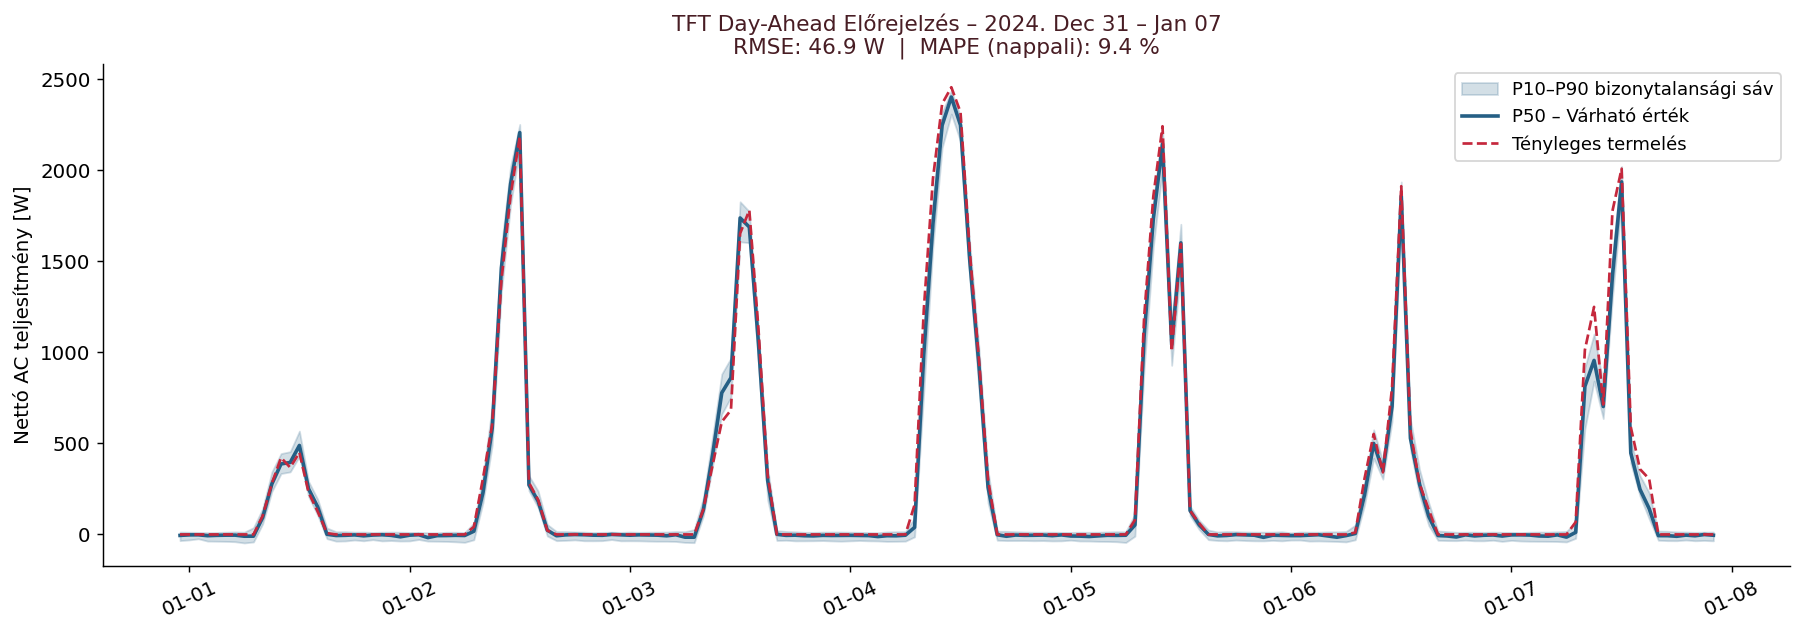

In [13]:
# Véletlen hét kiválasztása a tényleges backtest időszakból
bt_start    = backtest_p50.time_index[0]
bt_end      = backtest_p50.time_index[-1]
max_offset  = int((bt_end - bt_start).days / 7) - 1  # utolsó teljes hét indexe

week_offset = random.randint(0, max_offset)           # minden futáskor más hét
week_start  = bt_start + pd.Timedelta(weeks=week_offset)
week_end    = week_start + pd.Timedelta(days=6, hours=23)

print(f"Vizualizált hét: {week_start.date()} – {week_end.date()}  (offset: {week_offset}/{max_offset})")

# Adatok kivágása – az előre kiszámolt backtest_p10/p50/p90 változók újrahasználata
actual_week = ts_test_actual.slice(week_start, week_end).to_dataframe().squeeze()
p10_week    = backtest_p10.slice(week_start, week_end).to_dataframe().squeeze()
p50_week    = backtest_p50.slice(week_start, week_end).to_dataframe().squeeze()
p90_week    = backtest_p90.slice(week_start, week_end).to_dataframe().squeeze()

# Grafikon
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    p50_week.index, p10_week, p90_week,
    alpha=0.20, color=COLORS.get("ac", "#255f85"),
    label="P10–P90 bizonytalansági sáv",
)
ax.plot(
    p50_week.index, p50_week,
    color=COLORS.get("ac", "#255f85"), lw=2.0,
    label="P50 – Várható érték",
)
ax.plot(
    actual_week.index, actual_week,
    color=COLORS.get("loss", "#c5283d"), lw=1.5, ls="--",
    label="Tényleges termelés",
)

ax.set_title(
    f"TFT Day-Ahead Előrejelzés – {week_start.strftime('%Y. %b %d')} – {week_end.strftime('%b %d')}\n"
    f"RMSE: {rmse_val:.1f} W  |  MAPE (nappali): {mape_val:.1f} %",
    fontsize=12, color=COLORS.get("title", "#481d24"),
)
ax.set_ylabel("Nettó AC teljesítmény [W]")
ax.set_xlabel("")
ax.legend(loc="upper right", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

---
## 12. (Opcionális) Modell mentése / betöltése

In [14]:
# A mentés automatikus volt (save_checkpoints=True), a legjobb checkpoint újratölthető:
# model_loaded = TFTModel.load_from_checkpoint("solar_tft_model", best=True)

# Kézi mentés (opcionális):
model.save("solar_tft_model_manual.pt")

print("Modell checkpoint automatikusan mentve (save_checkpoints=True).")
print("Újratöltés: TFTModel.load_from_checkpoint('solar_tft_model', best=True)")

Modell checkpoint automatikusan mentve (save_checkpoints=True).
Újratöltés: TFTModel.load_from_checkpoint('solar_tft_model', best=True)


---
## 13. Vizualizáció – Napi MAPE Naptár Hőtérkép (2025)

Az egész tesztelési év (365 nap) előrejelzési hibáját egyetlen naptárszerű ábra mutatja. Minden négyzet egy napot jelöl; a szín intenzitása a napi MAPE értéket kódolja (csak nappali, > 5 W termelésű órák alapján számolva).

- **Zöld** napok: a TFT szinte tökéletesen megjósolta a termelést
- **Piros** napok: bizonytalan időjárás (borult, változékony), ahol a fizikai szimulációs előrejelzés is nehéz lenne
- **Szürke** cellák: téli napok, ahol gyakorlatilag nincs nappali termelés (MAPE értelmezhetetlen)

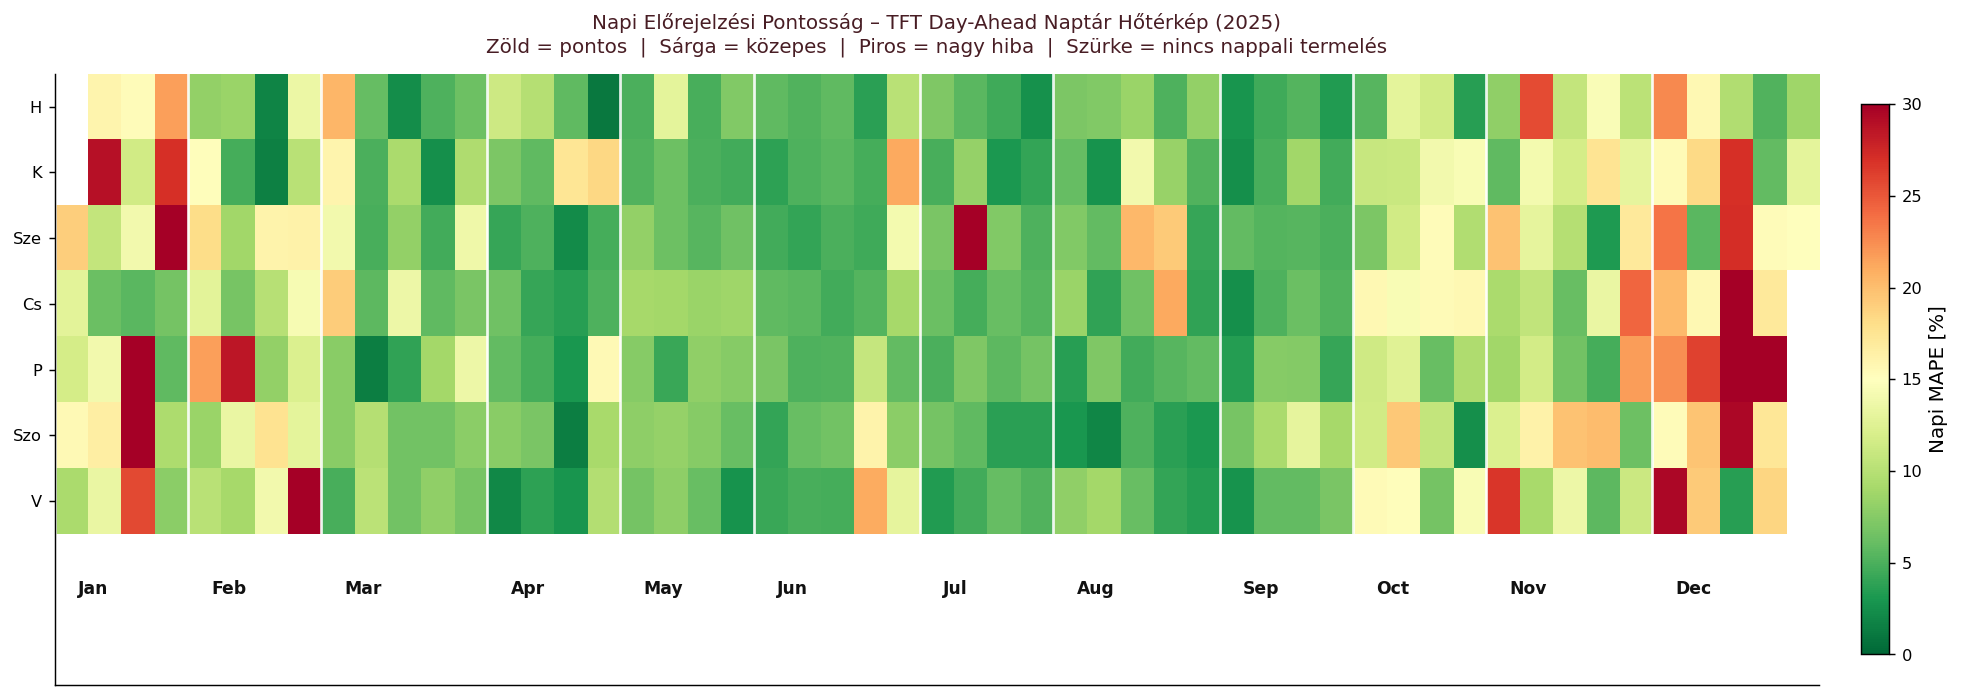

Legjobb nap   : 2025-04-21  →  MAPE = 1.2 %
Legrosszabb   : 2025-07-09  →  MAPE = 41.4 %
Éves átlag    : 10.0 %  (napsütéses napok)


In [15]:
# ─── 13. Vizualizáció: Napi MAPE Naptár Hőtérkép (2025) ────────────────────────

# Helyi idő közelítése UTC+1-gyel (CET, DST figyelmen kívül – vizualizációhoz elegendő)
_local_idx = actual_s.index + pd.Timedelta(hours=1)
_tmp = pd.DataFrame({"actual": actual_s.values, "p50": p50_s.values}, index=_local_idx)
_tmp = _tmp[_tmp.index.year == 2025]

def _day_mape(grp):
    _mask = grp["actual"] > 5.0
    if _mask.sum() < 2:
        return np.nan
    return (np.abs((grp.loc[_mask, "actual"] - grp.loc[_mask, "p50"])
                    / grp.loc[_mask, "actual"]).mean() * 100)

_daily_mape_s    = _tmp.groupby(_tmp.index.date).apply(_day_mape)
_daily_mape_dict = _daily_mape_s.to_dict()      # datetime.date → float

_year     = 2025
_all_days = pd.date_range(f"{_year}-01-01", f"{_year}-12-31", freq="D")
_dow0     = _all_days[0].dayofweek              # Jan 1 napja (2025 = 2, Szerda)

# Calendar grid: 7 sor (nap) × 54 oszlop (hét)
_grid = np.full((7, 54), np.nan)
for _d in _all_days:
    _i   = (_d - _all_days[0]).days
    _col = (_i + _dow0) // 7
    _row = _d.dayofweek
    _val = _daily_mape_dict.get(_d.date(), np.nan)
    if isinstance(_val, (int, float)) and not np.isnan(_val):
        _grid[_row, _col] = float(_val)

fig, ax = plt.subplots(figsize=(17, 5.5))
_im = ax.imshow(_grid, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=30, origin="upper")
_cb = plt.colorbar(_im, ax=ax, label="Napi MAPE [%]", shrink=0.9, pad=0.02)
_cb.ax.tick_params(labelsize=9)

# Hónaphatárok + feliratok közvetlenül a rács alatt (y=7.2)
_prev_mon = None
for _d in _all_days:
    _i   = (_d - _all_days[0]).days
    _col = (_i + _dow0) // 7
    if _d.month != _prev_mon:
        ax.axvline(_col - 0.5, color="white", lw=1.5, alpha=0.9)
        ax.text(_col + 0.2, 7.2, _d.strftime("%b"), fontsize=9.5,
                color="#111111", fontweight="bold", va="top", ha="left")
        _prev_mon = _d.month

# Ylim: szoros felül (-0.5), épp annyi alul, hogy a feliratok elférjenek (8.8)
ax.set_ylim(8.8, -0.5)
ax.set_yticks(range(7))
ax.set_yticklabels(["H", "K", "Sze", "Cs", "P", "Szo", "V"], fontsize=9)
ax.set_xticks([])
ax.set_xlim(-0.5, 52.5)
ax.set_title(
    "Napi Előrejelzési Pontosság – TFT Day-Ahead Naptár Hőtérkép (2025)\n"
    "Zöld = pontos  |  Sárga = közepes  |  Piros = nagy hiba  |  Szürke = nincs nappali termelés",
    fontsize=11, color=COLORS.get("title", "#481d24"), pad=12,
)
plt.tight_layout()
plt.show()

_no_nan = _daily_mape_s.dropna()
print(f"Legjobb nap   : {_no_nan.idxmin()}  →  MAPE = {_no_nan.min():.1f} %")
print(f"Legrosszabb   : {_no_nan.idxmax()}  →  MAPE = {_no_nan.max():.1f} %")
print(f"Éves átlag    : {_no_nan.mean():.1f} %  (napsütéses napok)")


---
## 14. Vizualizáció – Hónap × Óra Átlagos Termelési Profil

Ez a 3 paneles hőtérkép egyszerre mutatja az **évszakos** és **napszakos** mintázatokat.

- **Bal panel:** Tényleges mért termelés átlaga (hónap × óra bontásban)
- **Középső panel:** TFT P50 előrejelzés – vizuálisan csaknem azonos a balhoz, ami a modell minőségét igazolja
- **Jobb panel:** Abszolút hiba – megmutatja, mely hónap/óra kombinációban téved a modell a legtöbbet (jellemzően a hajnali/alkonyi átmeneti sávokban)

Az **inverter clipping** hatása: a nyári déli sávban (Máj–Aug, 08–12 UTC) a termelési profil "levágódik" a 3 kW-os inverter korlátján.

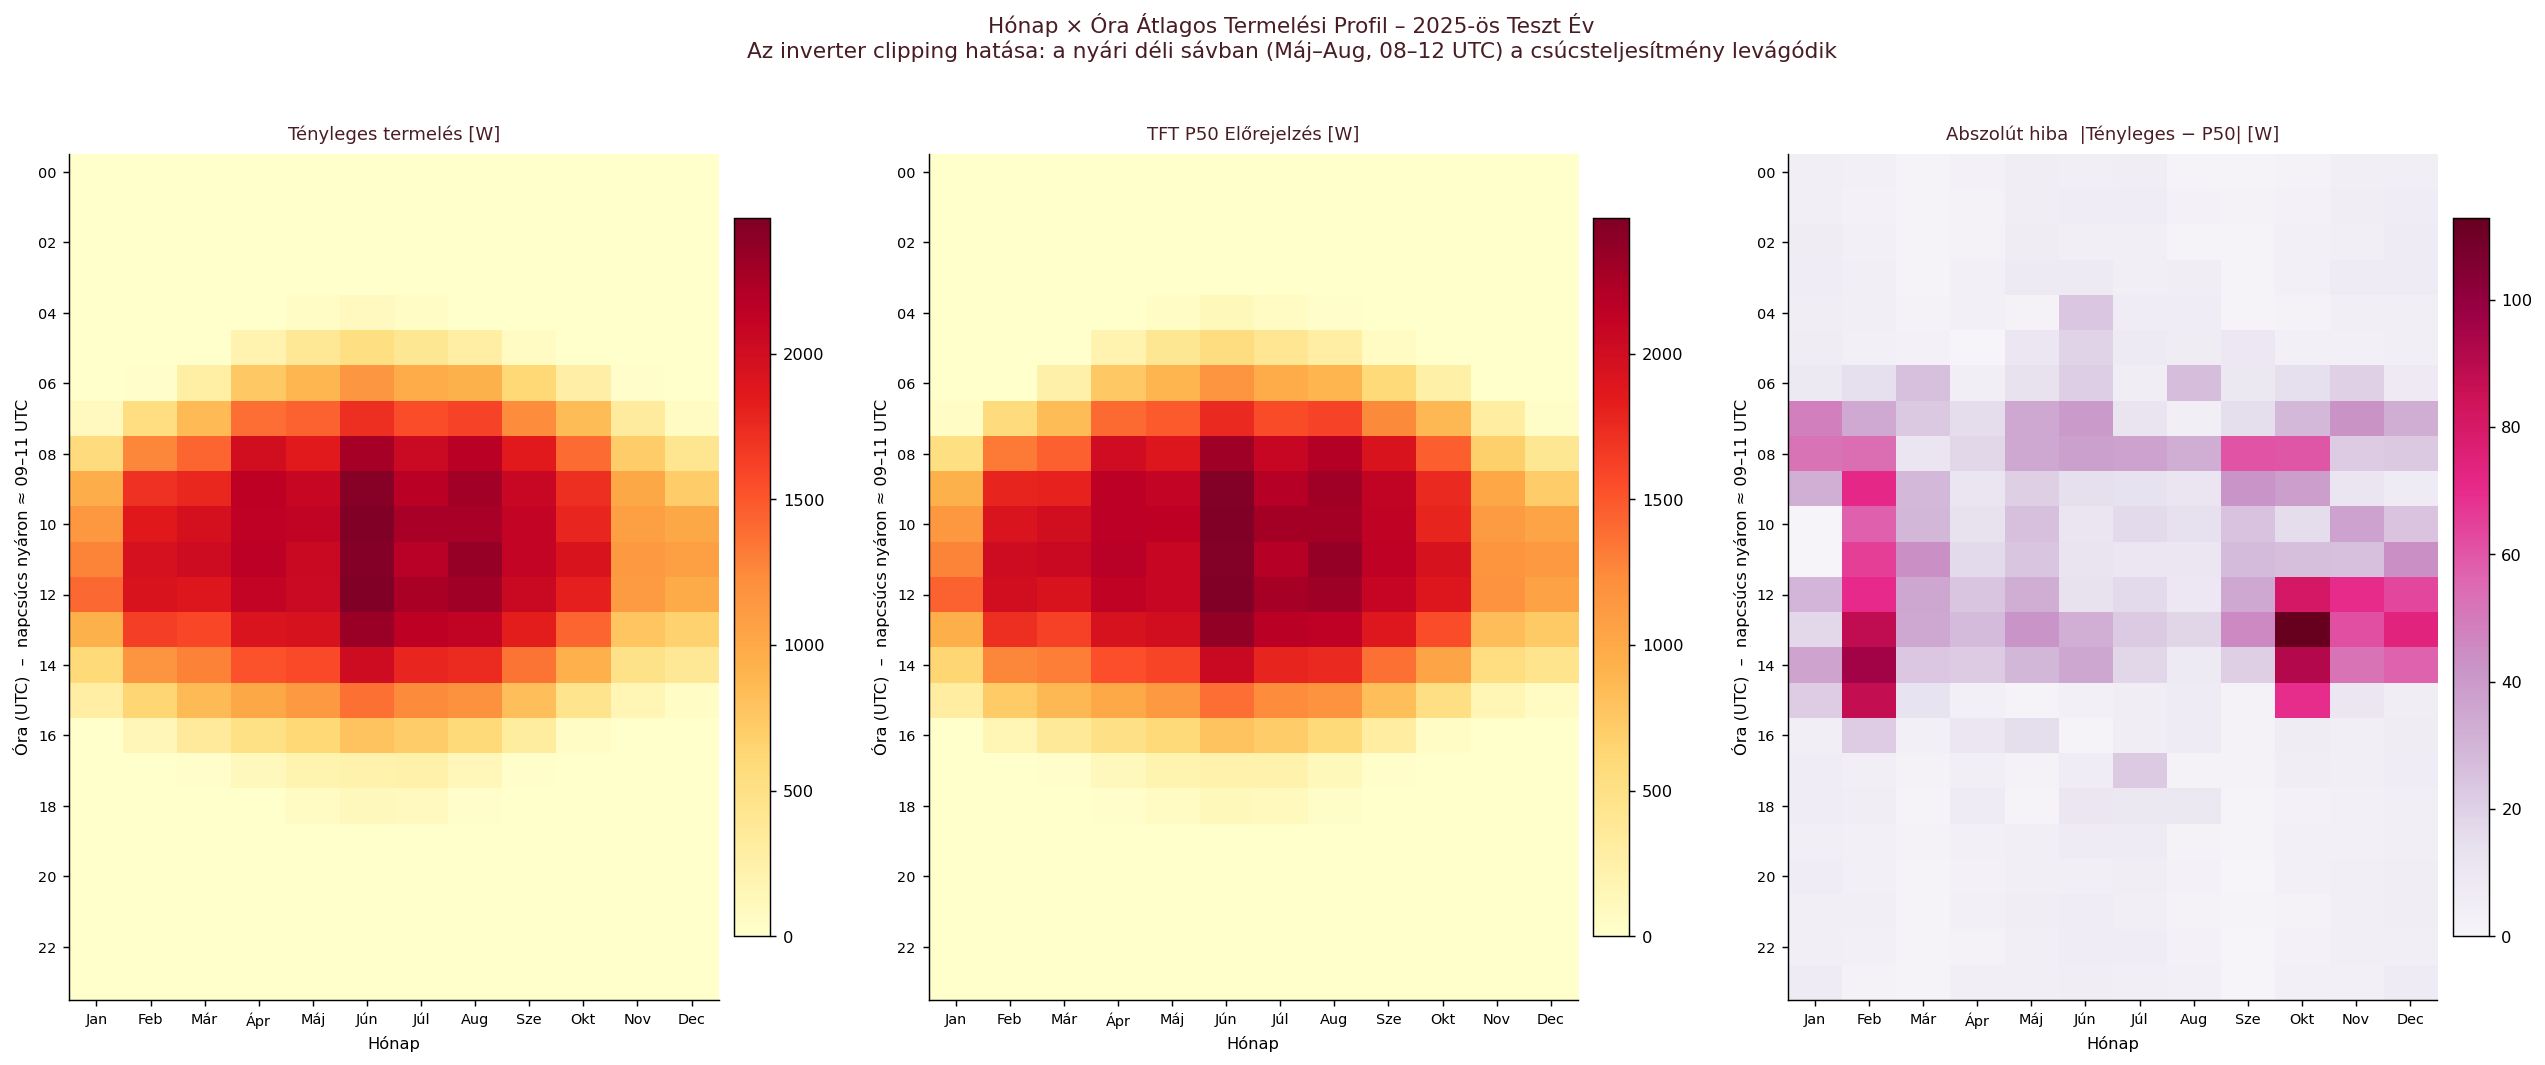

In [16]:
# ─── 14. Vizualizáció: Hónap × Óra Átlagos Termelési Profil (3 panel) ──────────

_df_hm = pd.DataFrame({
    "actual":    actual_s.values,
    "predicted": p50_s.values,
    "month":     actual_s.index.month,
    "hour":      actual_s.index.hour,
})

# Fektetett orientáció: hónap X-tengelyen (12 oszlop), óra Y-tengelyen (24 sor)
_piv_act  = _df_hm.groupby(["month", "hour"])["actual"].mean().unstack("month")
_piv_pred = _df_hm.groupby(["month", "hour"])["predicted"].mean().unstack("month")
_piv_err  = (_piv_act - _piv_pred).abs()

# Teljes 24×12 mátrix garantálva (hiányzó értékeket 0-val töltjük)
_piv_act  = _piv_act.reindex(index=range(24), columns=range(1, 13)).fillna(0.0)
_piv_pred = _piv_pred.reindex(index=range(24), columns=range(1, 13)).fillna(0.0)
_piv_err  = _piv_err.reindex(index=range(24), columns=range(1, 13)).fillna(0.0)

_MON = ["Jan", "Feb", "Már", "Ápr", "Máj", "Jún",
        "Júl", "Aug", "Sze", "Okt", "Nov", "Dec"]
_vmax_prod = float(np.nanmax([_piv_act.values.max(), _piv_pred.values.max()]))
_vmax_err  = float(np.nanmax(_piv_err.values))

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

_panels = [
    (_piv_act,  "YlOrRd", 0, _vmax_prod, "Tényleges termelés [W]"),
    (_piv_pred, "YlOrRd", 0, _vmax_prod, "TFT P50 Előrejelzés [W]"),
    (_piv_err,  "PuRd",   0, _vmax_err,  "Abszolút hiba  |Tényleges − P50| [W]"),
]
for ax, (piv, cmap, vmin, vmax, title) in zip(axes, _panels):
    _im = ax.imshow(piv.values, aspect="auto", cmap=cmap,
                    vmin=vmin, vmax=vmax, origin="upper")
    _cb = plt.colorbar(_im, ax=ax, shrink=0.85, pad=0.02)
    _cb.ax.tick_params(labelsize=9)
    ax.set_xticks(range(12))
    ax.set_xticklabels(_MON, fontsize=8)
    ax.set_yticks(range(0, 24, 2))
    ax.set_yticklabels([f"{h:02d}" for h in range(0, 24, 2)], fontsize=8)
    ax.set_xlabel("Hónap", fontsize=9)
    ax.set_ylabel("Óra (UTC)  –  napcsúcs nyáron ≈ 09–11 UTC", fontsize=9)
    ax.set_title(title, fontsize=10, color=COLORS.get("title", "#481d24"), pad=8)

fig.suptitle(
    "Hónap × Óra Átlagos Termelési Profil – 2025-ös Teszt Év\n"
    "Az inverter clipping hatása: a nyári déli sávban (Máj–Aug, 08–12 UTC) a csúcsteljesítmény levágódik",
    fontsize=12, color=COLORS.get("title", "#481d24"), y=1.02,
)
plt.tight_layout()
plt.show()